###Import Statements

In [3]:
import itertools
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import ast
import json
import csv


In [4]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
### --- Load Dataset (JSON version) --- ###
dataset_path = "/content/drive/MyDrive/Dissertation Work/Research Work/Datasets/medium_circuits.json"

# Load JSON into DataFrame
with open(dataset_path, "r") as f:
    data = json.load(f)

df_circuits = pd.DataFrame(data)

# Ensure numvars is int (if missing, infer from variables length)
if "numvars" in df_circuits.columns:
    df_circuits["numvars"] = df_circuits["numvars"].astype(int)
else:
    df_circuits["numvars"] = df_circuits["variables"].apply(len)

# Quick sanity print
for _, row in df_circuits.iterrows():
    print(row["circuit_name"], len(row["variables"]), len(row["gates"]))

hwb5_54 5 24
hwb6_57 6 65
ham7_104 7 23
cycle17_3_112 20 48
mod5adder_127 6 21
rd53_131 7 28
rd84_142 15 28
0410184_169 14 46
mux_246 22 35
ryy6_256 17 44
squar5_261 13 43
cycle10_293 39 78
hwb5_300 28 88
sym6_316 14 29


In [6]:
# # Ensure numvars is int
# if "numvars" in df_circuits.columns:
#     df_circuits["numvars"] = df_circuits["numvars"].astype(int)
# else:
#     # Fallback if column missing: infer from variables length
#     df_circuits["numvars"] = df_circuits["variables"].apply(len)

# # Quick sanity print
# for _, row in df_circuits.iterrows():
#     print(row["circuit_name"], len(row["variables"]), len(row["gates"]))

###Functions for fault model simulation and fault detection

In [7]:
# ---------- Fault Model ---------- #
def simulate_circuit(circuit, vec):
    """Simulate circuit on a boolean vector.

    Internal gate formats:
      ("TOFFOLI", controls_list, target_idx)
      ("FREDKIN", (controls_list, s1_idx, s2_idx))
    """
    v = vec.copy()
    for gate in circuit:
        gtype = gate[0]
        if gtype == "TOFFOLI":
            controls, target = gate[1], gate[2]
            if all(v[c] == 1 for c in controls):
                v[target] ^= 1
        elif gtype == "FREDKIN":
            controls_list, s1, s2 = gate[1]
            if all(v[c] == 1 for c in controls_list):
                v[s1], v[s2] = v[s2], v[s1]
        else:
            # Unknown gate type: ignore (or raise if you prefer)
            pass
    return v

In [8]:
def simulate_faulty_mmgf(circuit, input_vector, fault):
    """MMGF: missing gate at 'location'."""
    vec = input_vector.copy()
    faulty_circuit = []
    for i, gate in enumerate(circuit):
        if i == fault["location"]:
            continue
        faulty_circuit.append(gate)
    return simulate_circuit(faulty_circuit, vec)

In [9]:
def simulate_faulty_pmgf(circuit, input_vector, fault):
    vec = input_vector.copy()
    faulty_circuit = []
    for i, gate in enumerate(circuit):
        if i == fault["location"] and gate[0] == "TOFFOLI" and len(gate[1]) > 1:
            new_controls = gate[1][:]
            new_controls.remove(fault["removed_control"])
            faulty_circuit.append(("TOFFOLI", new_controls, gate[2]))
        else:
            faulty_circuit.append(gate)
    return simulate_circuit(faulty_circuit, vec)

In [10]:
def simulate_faulty_saf(circuit, input_vector, fault):
    """Simulate a circuit with a stuck-at fault (SAF)."""
    vec = input_vector.copy()

    for i, gate in enumerate(circuit):
        # Inject SAF at specific gate & wire
        if i == fault["location"]:
            vec[fault["wire"]] = fault["value"]

        gtype = gate[0].upper()

        if gtype == "TOFFOLI":
            controls, target = gate[1], gate[2]
            if all(vec[c] == 1 for c in controls):
                vec[target] ^= 1

        elif gtype == "FREDKIN":
            controls, s1, s2 = gate[1]
            if all(vec[c] == 1 for c in controls):
                vec[s1], vec[s2] = vec[s2], vec[s1]

        else:
            raise ValueError(f"Unknown gate type: {gtype}")

    return vec

In [11]:
def generate_gaf_faults(circuit, n_inputs):
    """
    Generate Gate Appearance Faults (GAF).
    For each gate, duplicate it once (appears twice in sequence).
    """
    fault_list = []
    for i, gate in enumerate(circuit):
        faulty_circuit = circuit[:i] + [gate, gate] + circuit[i+1:]
        fault_list.append({
            "id": f"GAF_{i}",
            "type": "GAF",
            "location": i,
            "circuit": faulty_circuit
        })
    return fault_list


In [12]:
def generate_fault_list_with_types(circuit, n_inputs):
    fault_list = []


    # # Single Missing Gate Faults (SMGF)
    # for i in range(len(circuit)):
    #     faulty_circuit = circuit[:i] + circuit[i+1:]
    #     fault_list.append({
    #         "id": f"SMGF_{i}",
    #         "type": "SMGF",
    #         "location": i,
    #         "circuit": faulty_circuit
    #     })

    # # Partial Missing Gate Faults (PMGF)
    # for i, gate in enumerate(circuit):
    #     if gate[0] == "TOFFOLI" and len(gate[1]) > 1:
    #         for ctrl in gate[1]:
    #             fault_list.append({
    #                 "id": f"PMGF_{i}_{ctrl}",
    #                 "type": "PMGF",
    #                 "location": i,
    #                 "removed_control": ctrl,
    #                 "circuit": circuit
    #             })


    # for i, gate in enumerate(circuit):
    #     fault_list.append({
    #         "id": f"MMGF_{i}",
    #         "type": "MMGF",
    #         "location": i,
    #         "gate": gate,
    #         "circuit": circuit
    #     })

    # # Stuck-at Faults
    # for gate_idx in range(len(circuit)):
    #     for wire in range(n_inputs):
    #         for val in [0, 1]:
    #             fault_list.append({
    #                 "id": f"SAF_{gate_idx}_{wire}_{val}",
    #                 "type": "SAF",
    #                 "location": gate_idx,
    #                 "wire": wire,
    #                 "value": val,
    #                 "circuit": circuit
    #             })

    # Gate Appearance Faults (GAF)
    fault_list.extend(generate_gaf_faults(circuit, n_inputs))

    return fault_list

In [13]:
def detect_fault(dp, vector, fault, circuit, normal_cache):
    """Detect a single fault using caching (works for SAF, MMGF, etc.)."""
    vkey = tuple(vector)
    if vkey not in normal_cache:
        normal_cache[vkey] = simulate_circuit(circuit, vector)
    normal_output = normal_cache[vkey]

    # Standardize fault_id
    fault_id = fault["id"] if isinstance(fault, dict) else str(fault)

    key = (vkey, fault_id)
    if key in dp:
        return dp[key]

    # Fault simulation dispatch
    if fault["type"] == "SAF":
        faulty_output = simulate_faulty_saf(circuit, vector, fault)
    elif fault["type"] == "MMGF":
        faulty_output = simulate_faulty_mmgf(circuit, vector, fault)
    elif fault["type"] == "SMGF":
        faulty_output = simulate_circuit(fault["circuit"], vector)
    elif fault["type"] == "PMGF":
        faulty_output = simulate_faulty_pmgf(circuit, vector, fault)
    elif fault["type"] == "GAF":
        faulty_output = simulate_circuit(fault["circuit"], vector)
    else:
        raise ValueError(f"Unknown fault type: {fault['type']}")

    detected = normal_output != faulty_output
    dp[key] = detected
    return detected


###Fitness Calulation

In [14]:
def compute_fitness(individual, fault_list, circuit, dp, alpha=100, beta=0.01):
    detected_faults = set()
    normal_cache = {}
    for vector in individual:
        for fault in fault_list:
            if detect_fault(dp, vector, fault, circuit, normal_cache):
                detected_faults.add(fault["id"])
    coverage = len(detected_faults) / len(fault_list) if fault_list else 0.0
    if coverage < 1.0:
        fitness = alpha * coverage
    else:
        fitness = alpha * coverage - beta * len(individual)
    return fitness, coverage, detected_faults

###Mutation and Crossover

In [15]:
# ---------- GA Operators ---------- #
def crossover(parent1, parent2):
    cut1 = random.randint(1, len(parent1) - 1)
    cut2 = random.randint(1, len(parent2) - 1)
    return parent1[:cut1] + parent2[cut2:]

def mutate(individual, mutation_rate=0.2):
    for vec in individual:
        if random.random() < mutation_rate:
            bit = random.randint(0, len(vec) - 1)
            vec[bit] ^= 1
    return individual

In [16]:
def remove_redundant_vectors(individual, circuit, fault_list):
    reduced = []
    dp = {}
    normal_cache = {}
    covered = set()
    for vec in individual:
        temp = covered.copy()
        for fault in fault_list:
            if fault["id"] not in covered and detect_fault(dp, vec, fault, circuit, normal_cache):
                covered.add(fault["id"])
        if temp != covered:
            reduced.append(vec)
    return reduced

###GA+DP Approach

In [17]:
### GA (Directed Only) ###

def run_ga_directed(circuit, n_inputs, generations=100, pop_size=50, max_vecs=50, runs=5):

    fault_list = generate_fault_list_with_types(circuit, n_inputs)
    best_results = []

    for _ in range(runs):
        dp = {}
        normal_cache = {}

        # Directed patterns (all-0, all-1, one-hot, one-cold)
        directed_patterns = [
            [0]*n_inputs,
            [1]*n_inputs,
        ]
        for i in range(n_inputs):
            vec = [0]*n_inputs; vec[i] = 1
            directed_patterns.append(vec)
            vec2 = [1]*n_inputs; vec2[i] = 0
            directed_patterns.append(vec2)

        # ---- PURE DIRECTED INITIALIZATION ----
        population = [
            random.sample(
                directed_patterns,
                min(len(directed_patterns), random.randint(2, max_vecs))
            )
            for _ in range(pop_size)
        ]

        best_cov = 0
        no_improve = 0

        for gen in range(generations):
            fitness_scores = [compute_fitness(ind, fault_list, circuit, dp) for ind in population]
            population = [x for _, x in sorted(zip(fitness_scores, population), key=lambda z: z[0][0], reverse=True)]
            best_fit, best_cov_gen, _ = fitness_scores[0][0], fitness_scores[0][1], fitness_scores[0][2]

            if best_cov_gen > best_cov:
                best_cov = best_cov_gen
                no_improve = 0
            else:
                no_improve += 1

            if best_cov == 1.0 or no_improve > 10:
                break

            # --- elitism + GA operators ---
            next_gen = [population[0]]  # elitism
            while len(next_gen) < pop_size:
                p1, p2 = random.sample(population[:pop_size // 2], 2)
                child = crossover(p1, p2)
                child = mutate(child)  # mutation still flips bits
                next_gen.append(child)
            population = next_gen

        # best individual
        best = max(population, key=lambda ind: compute_fitness(ind, fault_list, circuit, dp)[0])
        best = remove_redundant_vectors(best, circuit, fault_list)
        best_fitness, coverage, detected_faults = compute_fitness(best, fault_list, circuit, dp)

        # (Optional) residual sweep with directed pool only
        all_fault_ids = set(f["id"] for f in fault_list)
        remaining_faults = all_fault_ids - detected_faults
        if remaining_faults:
            for fault in remaining_faults:
                for vec in directed_patterns:  # try each directed vector
                    if detect_fault(dp, vec, fault, circuit, normal_cache):
                        best.append(vec)
                        break
            best = remove_redundant_vectors(best, circuit, fault_list)
            best_fitness, coverage, detected_faults = compute_fitness(best, fault_list, circuit, dp)

        best_results.append((best, (best_fitness, coverage, len(fault_list), detected_faults)))

    return best_results


###Run over the benchmark circuits

In [18]:
def convert_dataset_gates(dataset_gates, variables):
    """Convert dataset gates (e.g., {'gate':'t3','vars':[...]} or 'f4', etc.)
       into internal tuples for simulator."""
    # Ensure variables is a list (not a string)
    if isinstance(variables, str):
        variables = ast.literal_eval(variables)

    var_map = {v: i for i, v in enumerate(variables)}
    circuit = []

    for g in dataset_gates:
        # Defensive: skip malformed entries
        if not isinstance(g, dict) or "gate" not in g or "vars" not in g:
            continue

        gate_name = str(g["gate"]).lower()   # e.g., 't3', 'f4'
        names = g["vars"]                    # variable names
        # Map names -> indices (skip names not found)
        idxs = [var_map[n] for n in names if n in var_map]
        if len(idxs) == 0:
            continue

        if gate_name.startswith('t'):
            # Toffoli: last is target, others are controls
            if len(idxs) == 1:
                controls, target = [], idxs[0]
            else:
                controls, target = idxs[:-1], idxs[-1]
            circuit.append(("TOFFOLI", controls, target))

        elif gate_name.startswith('f'):
            # Fredkin: last two are swap targets, preceding are controls (can be 0,1, or many)
            if len(idxs) < 2:
                continue
            controls = idxs[:-2]
            s1, s2 = idxs[-2], idxs[-1]
            circuit.append(("FREDKIN", (controls, s1, s2)))

        else:
            # Unknown gate family → ignore (or map to NOT if 1-ary, etc.)
            # If you want NOT: if len(idxs)==1: circuit.append(("TOFFOLI", [], idxs[0]))
            pass

    return circuit

In [19]:
def run_on_dataset(df, save_csv_path="ga_results.csv"):
    results = []
    for _, row in df.iterrows():
        variables = row["variables"]
        circuit = convert_dataset_gates(row["gates"], variables)
        n_inputs = int(row["numvars"])
        if not circuit:
            print(f"⚠️ {row['circuit_name']} skipped.")
            continue
        start_time = time.time()
        best_runs = run_ga_directed(circuit, n_inputs)
        end_time = time.time()
        execution_time = round(end_time - start_time, 2)

        best_test_set, (fitness, coverage, total_faults, detected_faults) = max(
            best_runs, key=lambda x: x[1][0]
        )
        results.append({
            "file": row['circuit_name'],
            "fitness": round(fitness, 4),
            "coverage": round(coverage, 4),
            "total_faults": total_faults,
            "detected_faults": len(detected_faults),
            "test_vectors": best_test_set,
            "num_test_vectors": len(best_test_set),
            "num_gates": len(circuit),
            "exec_time_sec": execution_time
        })

    # save csv
    with open(save_csv_path, "w", newline='') as f:
        writer = csv.DictWriter(f, fieldnames=["file","fitness","coverage","total_faults","detected_faults","num_test_vectors","num_gates","exec_time_sec"])
        writer.writeheader()
        for row in results:
            writer.writerow({key: row[key] for key in writer.fieldnames})
    return results

###Visualiza the Results

In [20]:
def plot_gates_coverage_vectors(results):
    files = [r["file"] for r in results]
    num_gates = [r["num_gates"] for r in results]
    coverage = [r["coverage"] for r in results]
    num_vectors = [r["num_test_vectors"] for r in results]

    x = np.arange(len(files))
    fig, ax1 = plt.subplots(figsize=(14, 6))
    bars = ax1.bar(x - 0.2, num_gates, width=0.4, color='lightcoral', label="Gate Count")
    ax1.set_ylabel("Number of Gates", color="lightcoral")
    ax1.tick_params(axis='y', labelcolor="lightcoral")
    ax1.set_xticks(x)
    ax1.set_xticklabels(files, rotation=45, ha='right')

    ax2 = ax1.twinx()
    ax2.plot(x, coverage, marker='o', label="Fault Coverage")
    ax2.set_ylabel("Coverage")
    ax2.set_ylim(0, 1.05)

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(x, num_vectors, marker='s', linestyle='--', label="Test Vectors")
    ax3.set_ylabel("Number of Test Vectors")

    plt.title("Gates, Coverage & Test Vectors per Circuit")
    fig.tight_layout()
    plt.show()


def plot_coverage_vs_vectors(results):
    x = [r["num_test_vectors"] for r in results]
    y = [r["coverage"] for r in results]
    labels = [r["file"] for r in results]
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, s=100)
    for i, label in enumerate(labels):
        plt.text(x[i] + 0.02, y[i], label, fontsize=9)
    plt.xlabel("Number of Test Vectors")
    plt.ylabel("Fault Coverage")
    plt.title("Coverage vs Number of Test Vectors")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_efficiency(results):
    efficiency = [(r["detected_faults"] / r["num_test_vectors"]) if r["num_test_vectors"] else 0 for r in results]
    labels = [r["file"] for r in results]
    plt.figure(figsize=(10, 5))
    plt.bar(labels, efficiency)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Efficiency (Detected Faults per Vector)")
    plt.title("Test Vector Efficiency per Circuit")
    plt.tight_layout()
    plt.show()

In [21]:
# Run GA + DP on the dataset
results = run_on_dataset(df_circuits, save_csv_path="/content/drive/MyDrive/Dissertation Work/Research Work/Results/directed_medium_gaf.csv")

In [22]:
def plot_faults_per_circuit(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]
    files = [r["file"] for r in filtered]
    total_faults = [r["total_faults"] for r in filtered]
    detected_faults = [r["detected_faults"] for r in filtered]

    x = np.arange(len(files))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    bar1 = ax.bar(x - width/2, total_faults, width, label="Total Faults", color='lightgray')
    bar2 = ax.bar(x + width/2, detected_faults, width, label="Detected Faults", color='mediumseagreen')

    ax.set_xlabel("Circuit")
    ax.set_ylabel("Number of Faults")
    ax.set_title("Total vs Detected Faults per Circuit")
    ax.set_xticks(x)
    ax.set_xticklabels(files, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y')

    plt.tight_layout()
    plt.show()


In [23]:
for r in results:
    print(f'{r["file"]} → gates: {r.get("num_gates")}, vectors: {r.get("num_test_vectors")}, time: {r.get("exec_time_sec")} sec')



hwb5_54 → gates: 24, vectors: 4, time: 0.24 sec
hwb6_57 → gates: 65, vectors: 5, time: 1.94 sec
ham7_104 → gates: 23, vectors: 5, time: 0.28 sec
cycle17_3_112 → gates: 48, vectors: 7, time: 24.8 sec
mod5adder_127 → gates: 21, vectors: 4, time: 0.18 sec
rd53_131 → gates: 28, vectors: 5, time: 0.26 sec
rd84_142 → gates: 28, vectors: 5, time: 0.97 sec
0410184_169 → gates: 46, vectors: 6, time: 1.12 sec
mux_246 → gates: 35, vectors: 11, time: 42.62 sec
ryy6_256 → gates: 44, vectors: 10, time: 23.17 sec
squar5_261 → gates: 43, vectors: 7, time: 2.93 sec
cycle10_293 → gates: 78, vectors: 5, time: 8.08 sec
hwb5_300 → gates: 88, vectors: 6, time: 6.12 sec
sym6_316 → gates: 29, vectors: 3, time: 0.54 sec


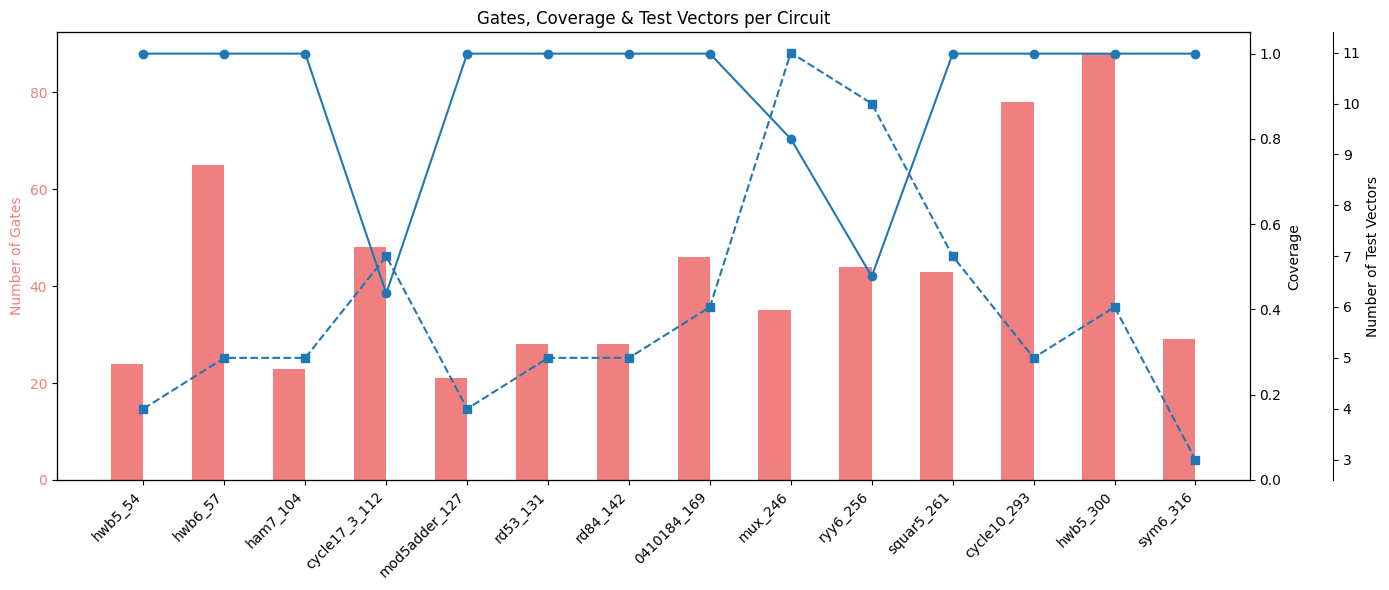

In [24]:
plot_gates_coverage_vectors(results)


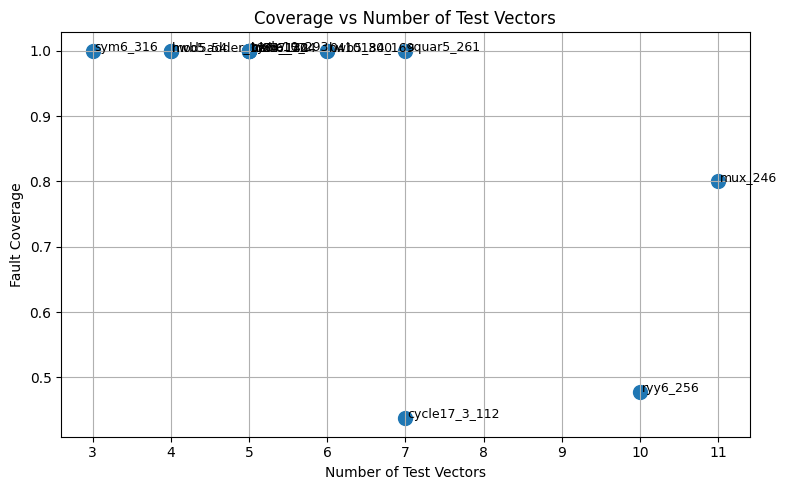

In [25]:
plot_coverage_vs_vectors(results)

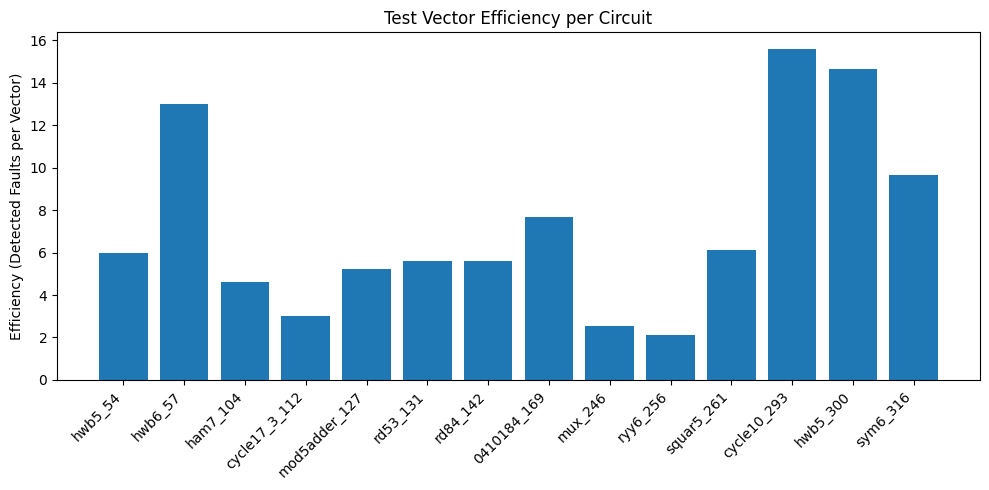

In [26]:
plot_efficiency(results)
# ---------- Example Execution ---------- #


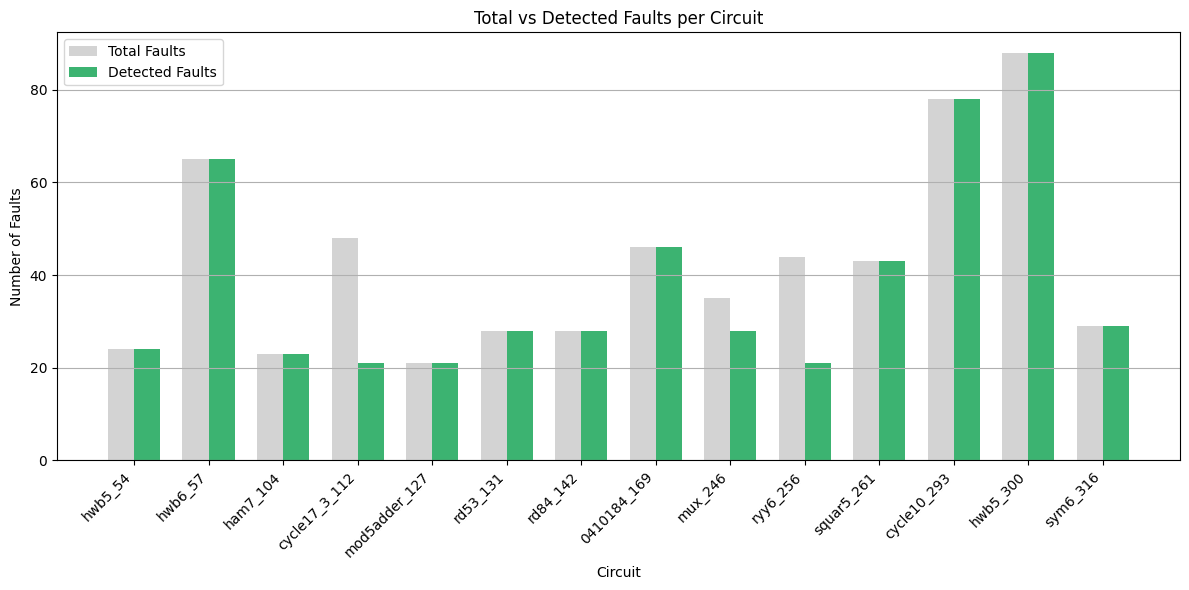

In [27]:
plot_faults_per_circuit(results)
